In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [5]:
patients = pd.read_csv("Rural_Healthcare_Dataset_3000_With_Season_And_Cough.csv")

medicine = pd.read_csv("Medicine_Stock_Data.csv")

In [8]:
patients.head()

,Patient_ID,Patient_Name,Age,Gender,Village,Visit_Date,Season,Disease,Medicine_Name,Quantity,Doctor
0,1,Patient_1,4,Female,Sonapur,2025-12-01,Winter,Fever,Paracetamol,1,Dr. Sharma
1,2,Patient_2,64,Female,Lakshmi Nagar,2025-11-25,Post-Monsoon,Diarrhoea,ORS,10,Dr. Deshmukh
2,3,Patient_3,2,Male,Rahatgaon,2026-05-19,Summer,Cough,Cough Syrup,1,Dr. Deshmukh
3,4,Patient_4,41,Male,Bhavanipur,2025-05-26,Summer,Common Cold,Cetirizine,10,Dr. Singh
4,5,Patient_5,33,Male,Khed,2025-03-12,Summer,Anaemia,Iron Tablets,3,Dr. Patil


In [9]:
medicine.head()

,Medicine_ID,Medicine_Name,Current_Stock,Reorder_Level,Stock_Status,Expiry_Date,Supplier,PHC_Name
0,M001,Paracetamol,500,120,In Stock,2027-06-30,ABC Pharma,Rampur PHC
1,M002,ORS,180,80,In Stock,2027-03-15,HealthMed,Rampur PHC
2,M003,Cough Syrup,75,50,Low Stock,2026-11-10,MediCare,Shivpur PHC
3,M004,Cetirizine,220,60,In Stock,2027-01-20,ABC Pharma,Shivpur PHC
4,M005,Amoxicillin,95,100,Low Stock,2026-12-25,LifeCare,Ganeshwadi PHC


In [10]:
print("Patients Columns")

print(patients.columns.tolist())

print()


Patients Columns
['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Village', 'Visit_Date', 'Season', 'Disease', 'Medicine_Name', 'Quantity', 'Doctor']



In [11]:
print("Medicine Columns")

print(medicine.columns.tolist())

Medicine Columns
['Medicine_ID', 'Medicine_Name', 'Current_Stock', 'Reorder_Level', 'Stock_Status', 'Expiry_Date', 'Supplier', 'PHC_Name']


In [12]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     3000 non-null   int64 
 1   Patient_Name   3000 non-null   object
 2   Age            3000 non-null   int64 
 3   Gender         3000 non-null   object
 4   Village        3000 non-null   object
 5   Visit_Date     3000 non-null   object
 6   Season         3000 non-null   object
 7   Disease        3000 non-null   object
 8   Medicine_Name  3000 non-null   object
 9   Quantity       3000 non-null   int64 
 10  Doctor         3000 non-null   object
dtypes: int64(3), object(8)
memory usage: 257.9+ KB


In [13]:
medicine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Medicine_ID    15 non-null     object
 1   Medicine_Name  15 non-null     object
 2   Current_Stock  15 non-null     int64 
 3   Reorder_Level  15 non-null     int64 
 4   Stock_Status   15 non-null     object
 5   Expiry_Date    15 non-null     object
 6   Supplier       15 non-null     object
 7   PHC_Name       15 non-null     object
dtypes: int64(2), object(6)
memory usage: 1.1+ KB


In [14]:
patients.isnull().sum()

Patient_ID       0
Patient_Name     0
Age              0
Gender           0
Village          0
Visit_Date       0
Season           0
Disease          0
Medicine_Name    0
Quantity         0
Doctor           0
dtype: int64

In [15]:
medicine.isnull().sum()

Medicine_ID      0
Medicine_Name    0
Current_Stock    0
Reorder_Level    0
Stock_Status     0
Expiry_Date      0
Supplier         0
PHC_Name         0
dtype: int64

In [16]:
patients.duplicated().sum()

np.int64(0)

In [17]:
medicine.duplicated().sum()

np.int64(0)

In [18]:
patients["Visit_Date"] = pd.to_datetime(
    patients["Visit_Date"]
)

In [19]:
medicine["Expiry_Date"] = pd.to_datetime(
    medicine["Expiry_Date"]
)

In [21]:
patients["Year"] = patients["Visit_Date"].dt.year


In [22]:
patients["Month"] = patients["Visit_Date"].dt.month

In [23]:
patients.describe(include="all")

,Patient_ID,Patient_Name,Age,Gender,Village,Visit_Date,Season,Disease,Medicine_Name,Quantity,Doctor,Year,Month
count,3000.000000,3000,3000.000000,3000,3000,3000,3000,3000,3000,3000.000000,3000,3000.000000,3000.000000
unique,NaN,3000,NaN,2,10,NaN,4,11,10,NaN,5,NaN,NaN
top,NaN,Patient_1,NaN,Female,Rahatgaon,NaN,Summer,Asthma,Paracetamol,NaN,Dr. Patil,NaN,NaN
freq,NaN,1,NaN,1505,331,NaN,1038,290,542,NaN,629,NaN,NaN
mean,1500.500000,NaN,43.988667,NaN,NaN,2025-09-29 09:46:33.600000256,NaN,NaN,NaN,5.469667,NaN,2025.331333,5.494333
min,1.000000,NaN,1.000000,NaN,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,1.000000,NaN,2025.000000,1.000000
25%,750.750000,NaN,23.000000,NaN,NaN,2025-05-16 00:00:00,NaN,NaN,NaN,3.000000,NaN,2025.000000,3.000000
50%,1500.500000,NaN,44.000000,NaN,NaN,2025-10-01 00:00:00,NaN,NaN,NaN,5.000000,NaN,2025.000000,5.000000
75%,2250.250000,NaN,66.000000,NaN,NaN,2026-02-11 00:00:00,NaN,NaN,NaN,8.000000,NaN,2026.000000,8.000000
max,3000.000000,NaN,85.000000,NaN,NaN,2026-06-25 00:00:00,NaN,NaN,NaN,10.000000,NaN,2026.000000,12.000000


In [24]:
medicine.describe(include="all")

,Medicine_ID,Medicine_Name,Current_Stock,Reorder_Level,Stock_Status,Expiry_Date,Supplier,PHC_Name
count,15,15,15.000000,15.000000,15,15,15,15
unique,15,15,NaN,NaN,3,NaN,7,5
top,M001,Paracetamol,NaN,NaN,In Stock,NaN,ABC Pharma,Rampur PHC
freq,1,1,NaN,NaN,11,NaN,4,3
mean,NaN,NaN,149.666667,67.333333,NaN,2027-03-05 03:12:00,NaN,NaN
min,NaN,NaN,0.000000,40.000000,NaN,2026-09-30 00:00:00,NaN,NaN
25%,NaN,NaN,87.500000,50.000000,NaN,2027-01-02 12:00:00,NaN,NaN
50%,NaN,NaN,130.000000,60.000000,NaN,2027-03-15 00:00:00,NaN,NaN
75%,NaN,NaN,175.000000,75.000000,NaN,2027-05-25 00:00:00,NaN,NaN
max,NaN,NaN,500.000000,120.000000,NaN,2027-08-10 00:00:00,NaN,NaN


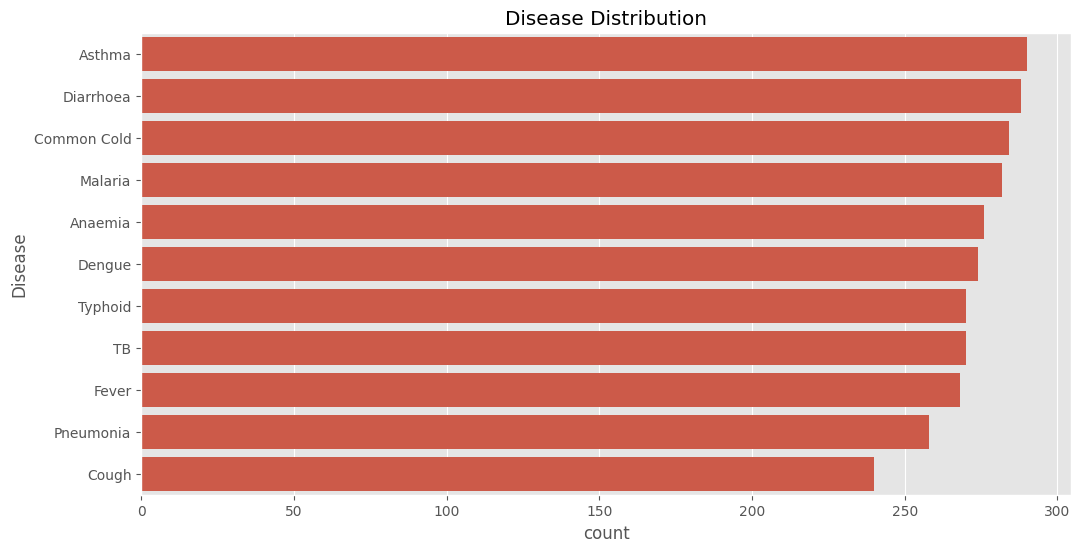

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=patients["Disease"],
    order=patients["Disease"].value_counts().index
)

plt.title("Disease Distribution")

plt.show()

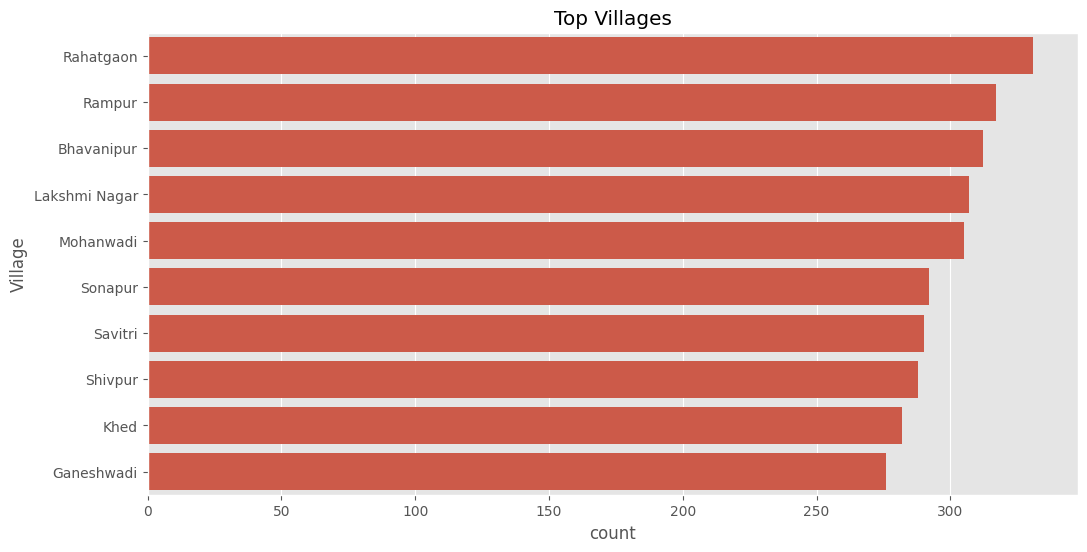

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=patients["Village"],
    order=patients["Village"].value_counts().head(15).index
)

plt.title("Top Villages")

plt.show()

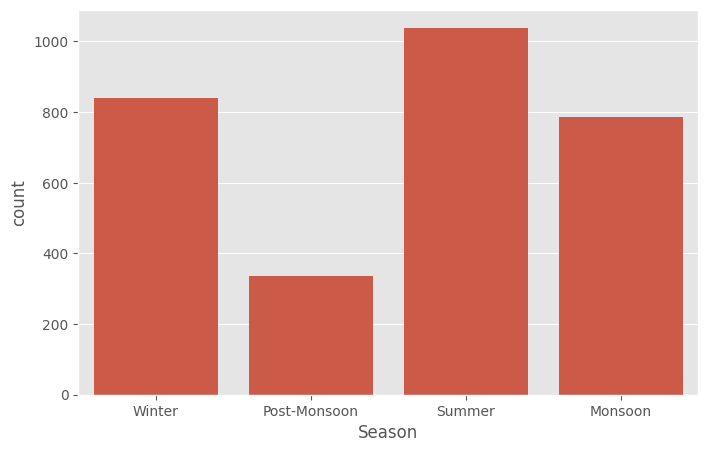

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x=patients["Season"])

plt.show()

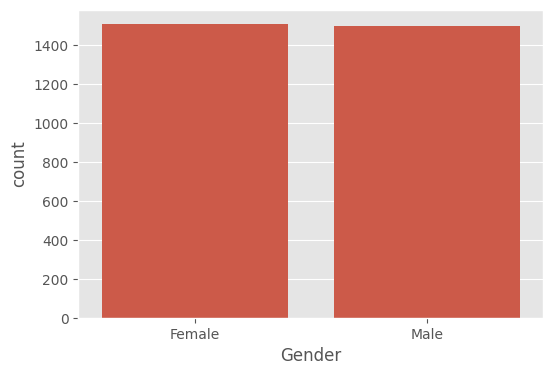

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x=patients["Gender"])

plt.show()

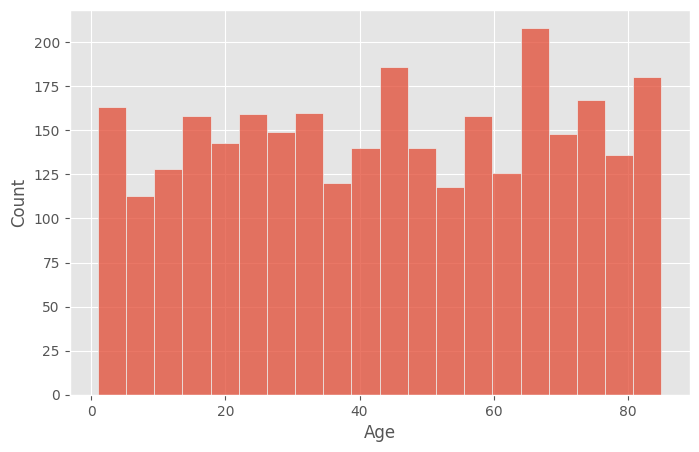

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    patients["Age"],
    bins=20
)

plt.show()

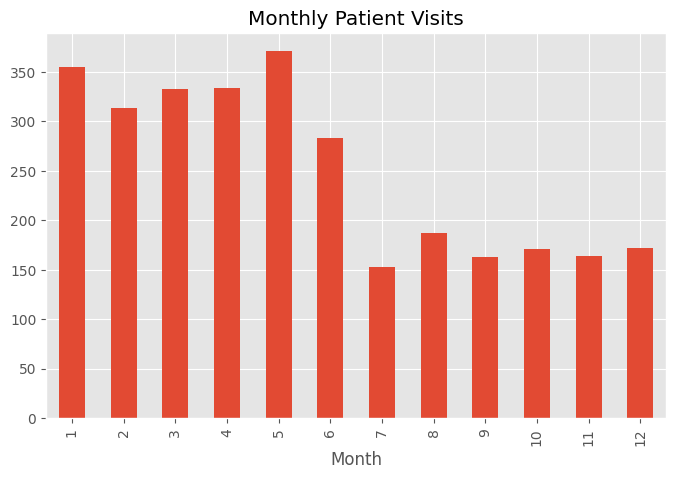

In [30]:
monthly = patients.groupby("Month").size()

monthly.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Monthly Patient Visits")

plt.show()

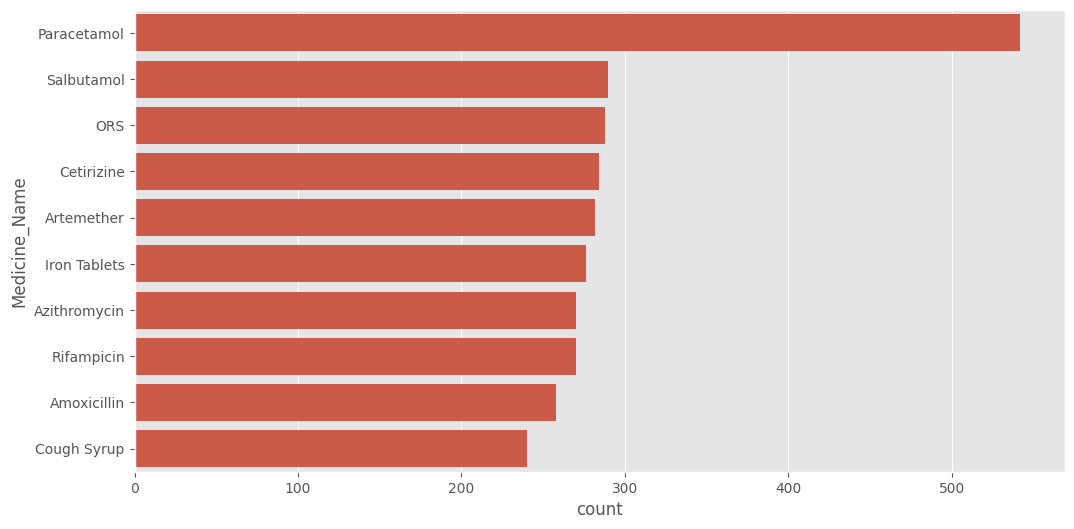

In [31]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=patients["Medicine_Name"],
    order=patients["Medicine_Name"].value_counts().index
)

plt.show()

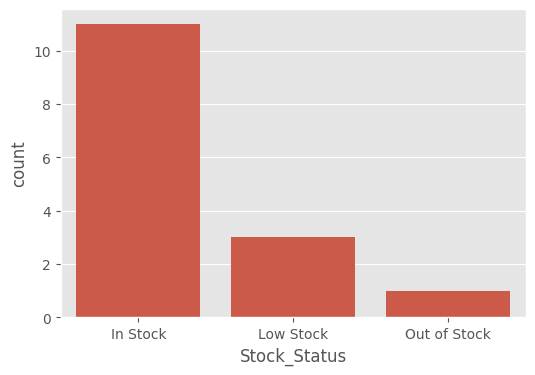

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=medicine["Stock_Status"]
)

plt.show()

In [33]:
low_stock = medicine[
    medicine["Current_Stock"] <= medicine["Reorder_Level"]
]

low_stock

,Medicine_ID,Medicine_Name,Current_Stock,Reorder_Level,Stock_Status,Expiry_Date,Supplier,PHC_Name
4,M005,Amoxicillin,95,100,Low Stock,2026-12-25,LifeCare,Ganeshwadi PHC
8,M009,Salbutamol,40,50,Low Stock,2026-10-05,MediCare,Savitri PHC
11,M012,Vitamin C,0,40,Out of Stock,2026-09-30,ABC Pharma,Shivpur PHC


In [35]:
import os

os.makedirs("processed", exist_ok=True)

patients.to_csv(
    "patients_cleaned.csv",
    index=False
)

medicine.to_csv(
    "medicine_cleaned.csv",
    index=False
)

print("Datasets saved successfully.")

Datasets saved successfully.
